# EDA: Предсказание выкупа заказа

**Цель:** Проанализировать данные о заказах медицинских товаров для построения модели предсказания вероятности выкупа заказа.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

DATA_PATH = Path("../data/raw/dataset_2025-03-01_2026-03-29_external.csv")

## 1. Загрузка и обзор данных

In [4]:
df = pd.read_csv(DATA_PATH)
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} колонок")
df.head()

/tmp/ipykernel_42276/72439419.py:1: DtypeWarning: Columns (0: lead_Оплата МОП, 1: lead_Счет оплачен, 2: lead_Название товара, 3: lead_Наименование получателя, 4: lead_ФИО, 5: lead_Адрес доставки, 6: contact_TelegramId_WZ, 7: lead_СМС-уведомления, 8: contact_TelegramUsername_WZ, 9: lead_Объявление, 10: lead_URL объявления, 11: lead_Поиск товаров GoSklad, 12: lead_Список товаров GoSklad, 13: lead_Колесо, 14: contact_Канал Callibri, 15: lead_ROISTAT_REFERRER, 16: lead_Категория и варианты выбора, 17: lead_Ссылка на документ, 18: lead_Выбранные товары, 19: contact_Ссылка на документ, 20: lead_Solo, 21: lead_YBAIP, 22: lead_from, 23: lead_Source phone, 24: lead_ИМ сдэк, 25: lead_Комментарий к отправлению, 26: lead_POLICY, 27: lead_LEADQUALIFYCATION, 28: lead_ROISTAT_POS, 29: lead_ROISTAT_FIELDS_ROISTAT, 30: lead_ROISTAT_URL, 31: lead_TEST-TAG, 32: lead_BANNER-SIZES, 33: lead_CTIME, 34: lead_BANNER-TEST-TAGS, 35: lead_BANNERS-VIDEOS, 36: lead_CONSTRUCTOR-RENDERED-ASSETS, 37: lead_RENDERED-DI

Размер датасета: 18887 строк, 191 колонок


,lead_id,sale_ts,sale_date,buyout_flag,outcome_unknown,handed_to_delivery_ts,issued_or_pvz_ts,received_ts,rejected_ts,returned_ts,...,lead_RS_STAT,lead_Номер линии билайн:,lead_ETEXT,lead_Ответственный за доставку,lead_AI_abcde,lead_YSCLID,contact_Max ID,lead_POLICY_MARKETING,lead_ASSET-CLICK,lead_URL
0,LEAD_0172,1740807306,2025-03-01,True,False,1.741339e+09,1.741782e+09,1.741782e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,LEAD_0176,1740808264,2025-03-01,True,False,1.741339e+09,1.741609e+09,1.741620e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,LEAD_0177,1740808445,2025-03-01,True,False,1.741254e+09,1.742355e+09,1.742366e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LEAD_0182,1740809886,2025-03-01,True,False,1.741170e+09,1.741516e+09,1.741620e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,LEAD_0180,1740811327,2025-03-01,True,False,1.741253e+09,1.741503e+09,1.741516e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
print("Типы данных:")
print(df.dtypes.value_counts())

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame(
    {"missing_count": missing, "missing_percent": missing_pct}
).sort_values("missing_percent", ascending=False)

print("\nКолонки с пропусками (>0%):")
print(missing_df[missing_df["missing_count"] > 0].head(20))

Типы данных:
str        129
float64     49
int64        8
bool         3
object       2
Name: count, dtype: int64

Колонки с пропусками (>0%):
                                               missing_count  missing_percent
contact_Канал Callibri                                 18884            100.0
contact_Ссылка на документ                             18884            100.0
lead_BANNER-TEST-TAGS                                  18885            100.0
contact_TelegramUsername_WZ                            18882            100.0
lead_ACTUAL-FORMAT                                     18885            100.0
lead_CTIME                                             18881            100.0
lead_BANNER-SIZES                                      18885            100.0
lead_TEST-TAG                                          18885            100.0
lead_Комментарий к отправлению                         18883            100.0
lead_СМС-уведомления                                   18884            100.0

## 2. Анализ целевой переменной

Распределение целевой переменной 'buyout_flag':
buyout_flag
True     14882
False     3084
Name: count, dtype: int64

Доля выкупа: 82.83%


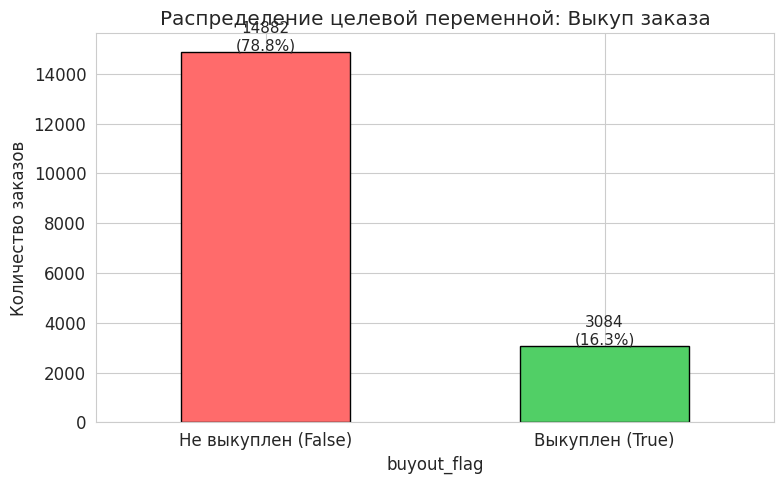

In [6]:
print("Распределение целевой переменной 'buyout_flag':")
print(df["buyout_flag"].value_counts())
print(f"\nДоля выкупа: {df['buyout_flag'].mean():.2%}")

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#ff6b6b", "#51cf66"]
df["buyout_flag"].value_counts().plot(
    kind="bar", color=colors, ax=ax, edgecolor="black"
)
ax.set_title("Распределение целевой переменной: Выкуп заказа")
ax.set_xlabel("buyout_flag")
ax.set_ylabel("Количество заказов")
ax.set_xticklabels(["Не выкуплен (False)", "Выкуплен (True)"], rotation=0)
for i, v in enumerate(df["buyout_flag"].value_counts()):
    ax.text(i, v + 50, f"{v}\n({v / len(df) * 100:.1f}%)", ha="center", fontsize=11)
plt.tight_layout()
plt.show()

## 3. Анализ признаков по группам

### 3.1 Временные признаки

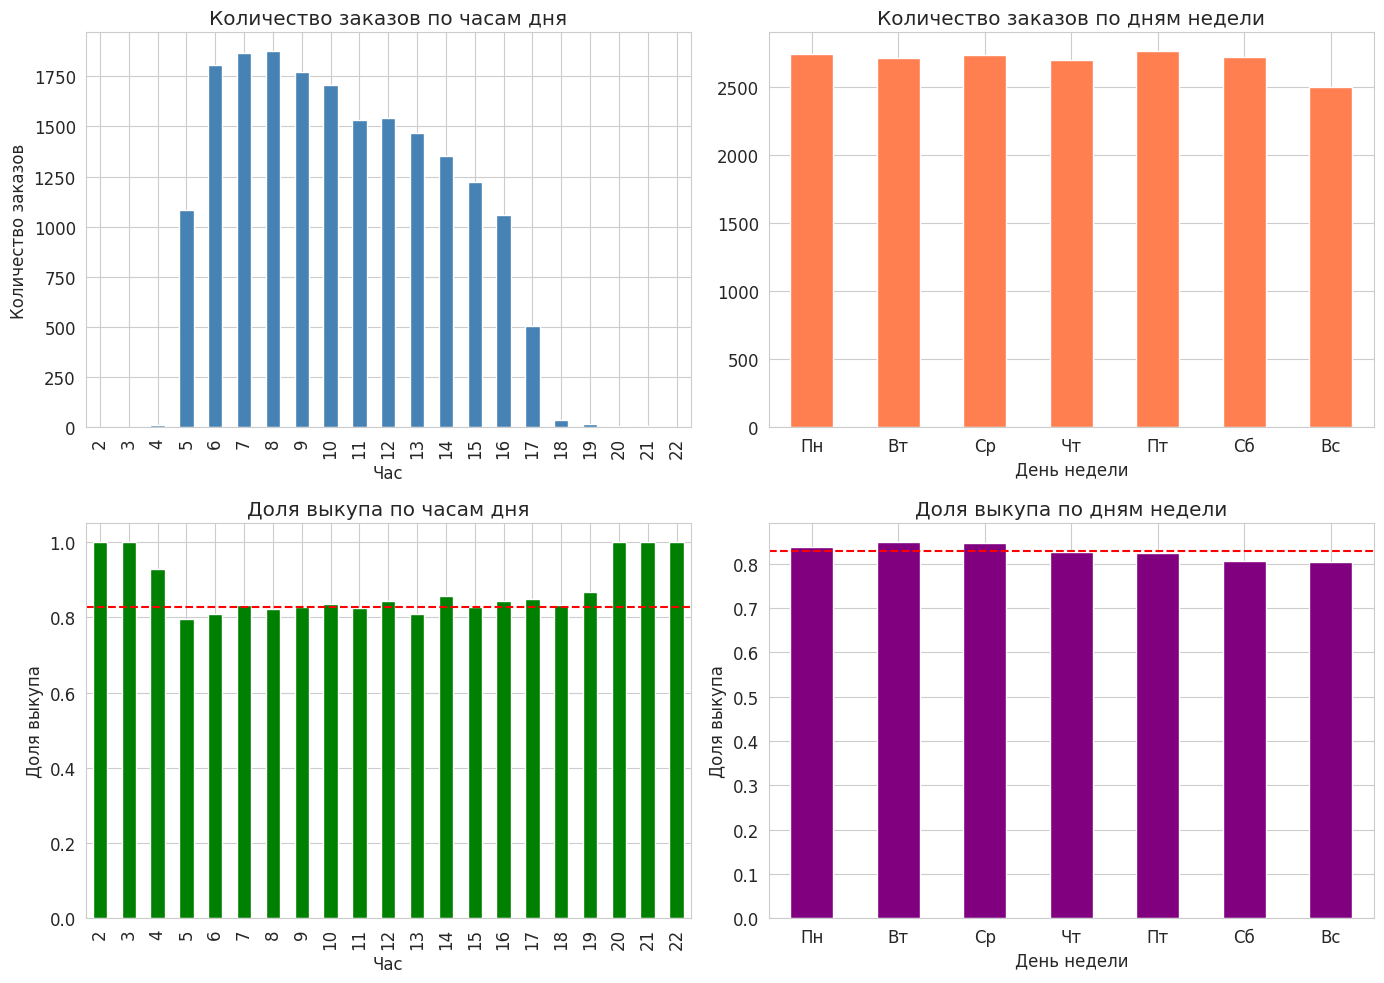

In [7]:
df["sale_datetime"] = pd.to_datetime(df["sale_ts"], unit="s")
df["created_datetime"] = pd.to_datetime(df["lead_created_at"], unit="s")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df.groupby(df["sale_datetime"].dt.hour).size().plot(
    kind="bar", ax=axes[0, 0], color="steelblue"
)
axes[0, 0].set_title("Количество заказов по часам дня")
axes[0, 0].set_xlabel("Час")
axes[0, 0].set_ylabel("Количество заказов")

days = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]
df.groupby(df["sale_datetime"].dt.dayofweek).size().plot(
    kind="bar", ax=axes[0, 1], color="coral"
)
axes[0, 1].set_title("Количество заказов по дням недели")
axes[0, 1].set_xlabel("День недели")
axes[0, 1].set_xticklabels(days, rotation=0)

hourly_buyout = df.groupby(df["sale_datetime"].dt.hour)["buyout_flag"].mean()
hourly_buyout.plot(kind="bar", ax=axes[1, 0], color="green")
axes[1, 0].set_title("Доля выкупа по часам дня")
axes[1, 0].set_xlabel("Час")
axes[1, 0].set_ylabel("Доля выкупа")
axes[1, 0].axhline(
    y=df["buyout_flag"].mean(), color="red", linestyle="--", label="Среднее"
)

daily_buyout = df.groupby(df["sale_datetime"].dt.dayofweek)["buyout_flag"].mean()
daily_buyout.plot(kind="bar", ax=axes[1, 1], color="purple")
axes[1, 1].set_title("Доля выкупа по дням недели")
axes[1, 1].set_xlabel("День недели")
axes[1, 1].set_xticklabels(days, rotation=0)
axes[1, 1].set_ylabel("Доля выкупа")
axes[1, 1].axhline(y=df["buyout_flag"].mean(), color="red", linestyle="--")

plt.tight_layout()
plt.show()

TypeError: A single argument passed to legend() must be a list of labels, but found an Artist in there.

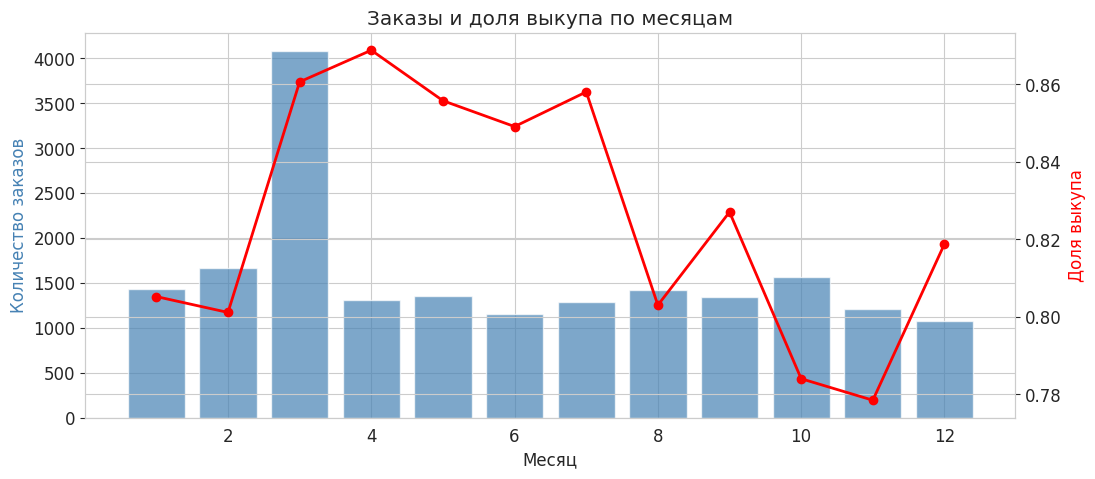

In [8]:
df["sale_month"] = df["sale_datetime"].dt.month

fig, ax = plt.subplots(figsize=(12, 5))
ax2 = ax.twinx()

grouped = df.groupby("sale_month")
counts = grouped.size()
rates = grouped["buyout_flag"].mean()

months = range(1, 13)

ax.bar(months, counts.values, color="steelblue", alpha=0.7, label="Количество заказов")
ax2.plot(months, rates.values, color="red", marker="o", linewidth=2, label="Доля выкупа")

ax.set_title("Заказы и доля выкупа по месяцам")
ax.set_xlabel("Месяц")
ax.set_ylabel("Количество заказов", color="steelblue")
ax2.set_ylabel("Доля выкупа", color="red")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, loc="upper right")

plt.tight_layout()
plt.show()


### 3.2 Финансовые признаки

In [ ]:
financial_cols = [
    "lead_price",
    "lead_Скидка",
    "lead_Сумма заказа",
    "lead_Стоимость доставки",
    "lead_Сумма наложенного платежа (руб)",
]

print("Статистика финансовых признаков:")
df[financial_cols].describe().round(2)

Статистика финансовых признаков:


,lead_price,lead_Скидка,lead_Сумма заказа,lead_Сумма наложенного платежа (руб)
count,18887.00,2769.00,710.00,3.049000e+03
mean,11683.29,13.26,9480.01,3.338776e+06
std,10167.70,5.93,11988.40,1.837279e+08
min,0.00,0.00,1465.00,1.416000e+03
25%,6612.50,10.00,4379.50,7.378000e+03
50%,9063.00,10.00,7255.00,9.260000e+03
75%,14560.00,15.00,9982.50,1.453800e+04
max,413432.00,40.00,190150.00,1.014505e+10


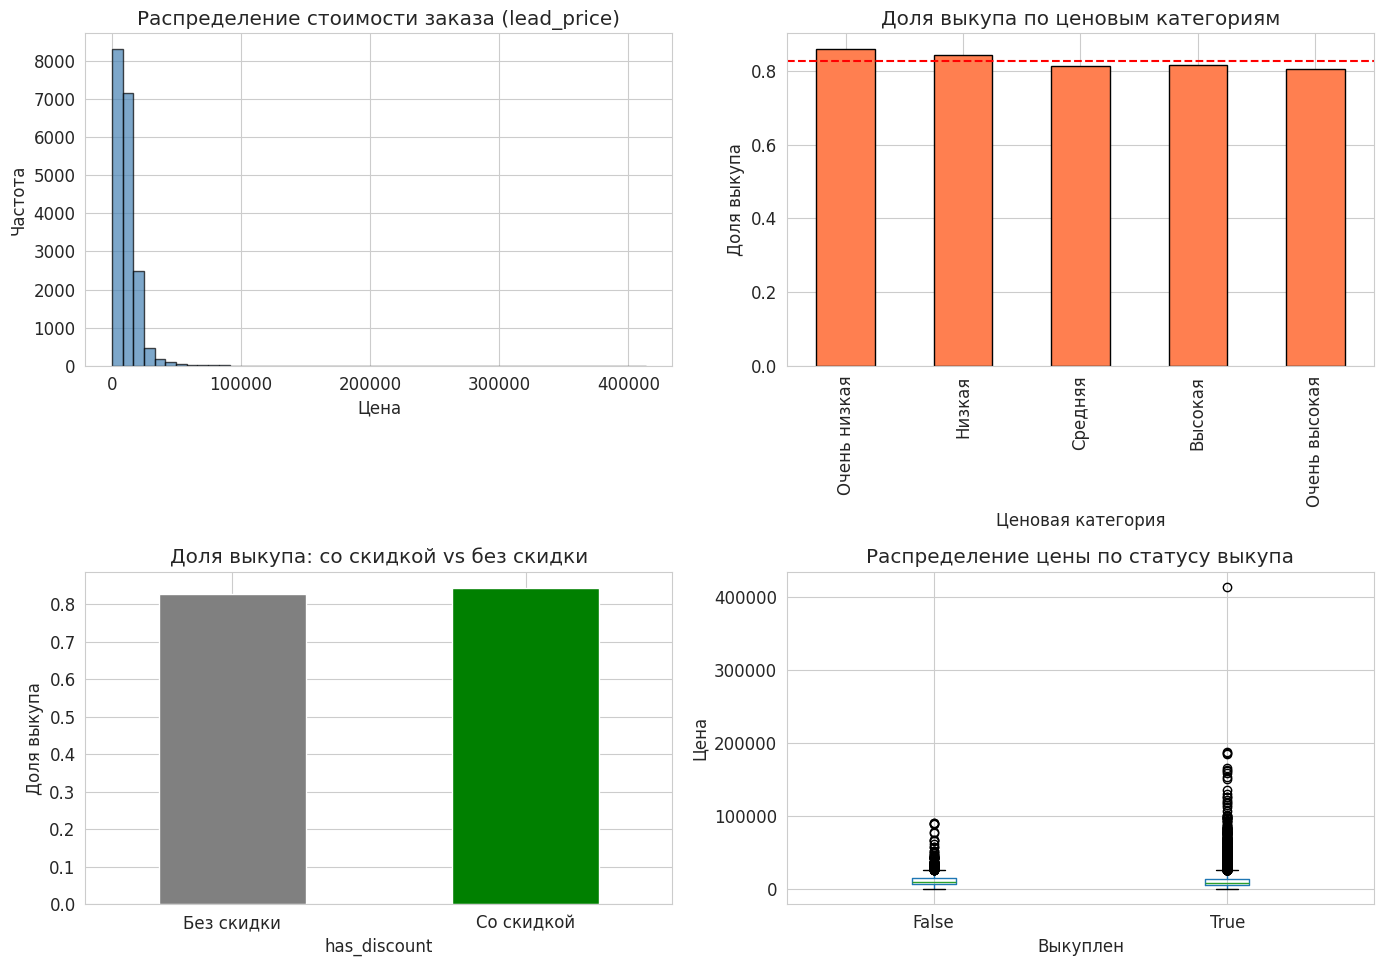

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(
    df["lead_price"].dropna(), bins=50, color="steelblue", edgecolor="black", alpha=0.7
)
axes[0, 0].set_title("Распределение стоимости заказа (lead_price)")
axes[0, 0].set_xlabel("Цена")
axes[0, 0].set_ylabel("Частота")

df["price_category"] = pd.qcut(
    df["lead_price"].dropna(),
    q=5,
    labels=["Очень низкая", "Низкая", "Средняя", "Высокая", "Очень высокая"],
)
df.groupby("price_category")["buyout_flag"].mean().plot(
    kind="bar", ax=axes[0, 1], color="coral", edgecolor="black"
)
axes[0, 1].set_title("Доля выкупа по ценовым категориям")
axes[0, 1].set_xlabel("Ценовая категория")
axes[0, 1].set_ylabel("Доля выкупа")
axes[0, 1].axhline(y=df["buyout_flag"].mean(), color="red", linestyle="--")

df["has_discount"] = (df["lead_Скидка"] > 0).astype(int)
df.groupby("has_discount")["buyout_flag"].mean().plot(
    kind="bar", ax=axes[1, 0], color=["gray", "green"]
)
axes[1, 0].set_title("Доля выкупа: со скидкой vs без скидки")
axes[1, 0].set_xticklabels(["Без скидки", "Со скидкой"], rotation=0)
axes[1, 0].set_ylabel("Доля выкупа")

df.boxplot(column="lead_price", by="buyout_flag", ax=axes[1, 1])
axes[1, 1].set_title("Распределение цены по статусу выкупа")
axes[1, 1].set_xlabel("Выкуплен")
axes[1, 1].set_ylabel("Цена")
plt.suptitle("")

plt.tight_layout()
plt.show()

### 3.3 Логистические признаки

In [ ]:
print("Служба доставки:")
print(df["lead_Служба доставки"].value_counts())

print("\nМетод доставки:")
print(df["lead_Метод доставки"].value_counts())

Служба доставки:
lead_Служба доставки
СДЭК до ПВЗ      13118
Почта             3217
СДЭК до Двери     2510
Самовывоз           25
Курьер ЕМС           2
Name: count, dtype: int64

Метод доставки:
lead_Метод доставки
В пункт выдачи товаров (СДЭК)    619
Курьером (СДЭК)                   90
СДЕК                               1
Name: count, dtype: int64


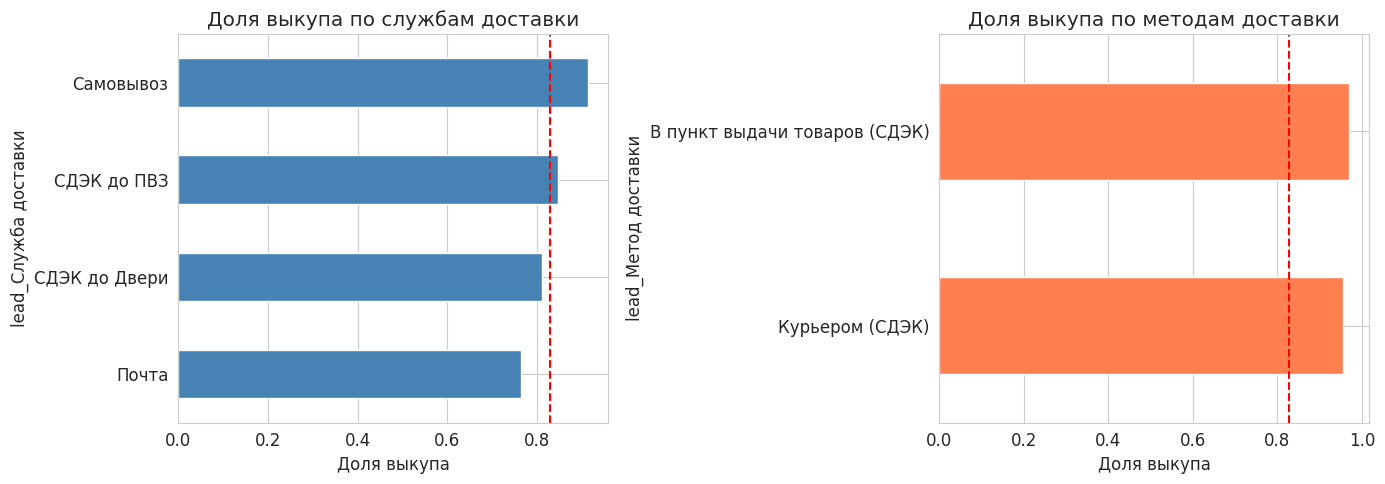

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

delivery_buyout = df.groupby("lead_Служба доставки")["buyout_flag"].agg(
    ["mean", "count"]
)
delivery_buyout = delivery_buyout[delivery_buyout["count"] >= 20].sort_values("mean")
delivery_buyout["mean"].plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Доля выкупа по службам доставки")
axes[0].set_xlabel("Доля выкупа")
axes[0].axvline(x=df["buyout_flag"].mean(), color="red", linestyle="--")

method_buyout = df.groupby("lead_Метод доставки")["buyout_flag"].agg(["mean", "count"])
method_buyout = method_buyout[method_buyout["count"] >= 20].sort_values("mean")
method_buyout["mean"].plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title("Доля выкупа по методам доставки")
axes[1].set_xlabel("Доля выкупа")
axes[1].axvline(x=df["buyout_flag"].mean(), color="red", linestyle="--")

plt.tight_layout()
plt.show()

### 3.4 Географические признаки

In [ ]:
print("Топ-20 городов по количеству заказов:")
city_stats = (
    df.groupby("contact_Город")
    .agg({"lead_id": "count", "buyout_flag": "mean"})
    .rename(columns={"lead_id": "count", "buyout_flag": "buyout_rate"})
)
city_stats = city_stats.sort_values("count", ascending=False).head(20)
print(city_stats.round(3))

Топ-20 городов по количеству заказов:
                 count buyout_rate
contact_Город                     
Москва            2172    0.858824
Санкт-Петербург    724    0.865906
Новосибирск        254    0.845188
Екатеринбург       228    0.825688
Краснодар          182    0.840909
Нижний Новгород    167    0.893082
Самара             165    0.851852
Челябинск          159    0.822368
Пермь              152    0.825503
Волгоград          139    0.856061
Тюмень             138    0.823077
Красноярск         137    0.801587
Казань             136    0.840909
Омск               135       0.864
Хабаровск          135    0.752066
Владивосток        129    0.857143
Уфа                127    0.798319
Воронеж            127       0.808
Ярославль          124    0.879032
Ростов-на-Дону     119    0.793103


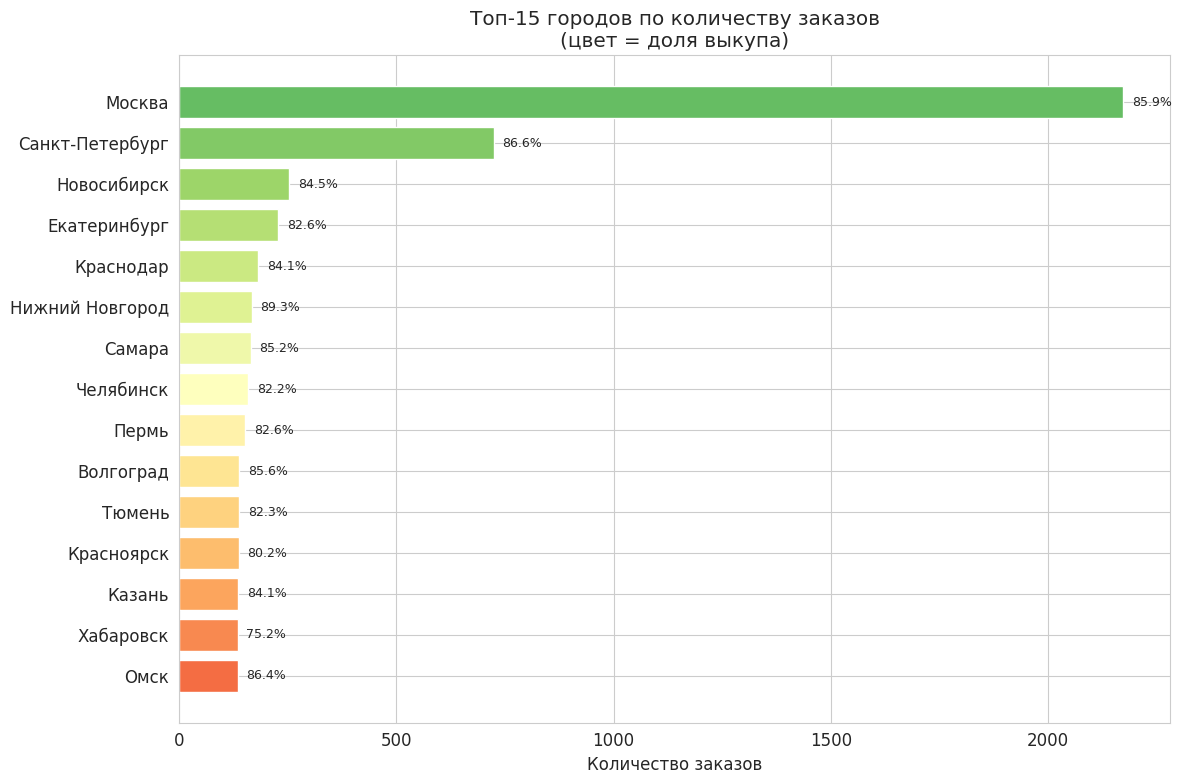

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

top_cities = city_stats.head(15).sort_values("count")

min_rate = top_cities["buyout_rate"].astype(float).min()
max_rate = top_cities["buyout_rate"].astype(float).max()
if max_rate > min_rate:
    norm_rates = 0.2 + 0.6 * (top_cities["buyout_rate"].astype(float) - min_rate) / (max_rate - min_rate)
else:
    norm_rates = [0.5] * len(top_cities)

colors = plt.cm.RdYlGn(norm_rates.values)

bars = ax.barh(top_cities.index, top_cities["count"], color=colors)
ax.set_title("Топ-15 городов по количеству заказов\n(цвет = доля выкупа)")
ax.set_xlabel("Количество заказов")

for i, (city, row) in enumerate(top_cities.iterrows()):
    ax.text(row["count"] + 20, i, f"{row['buyout_rate']:.1%}", va="center", fontsize=9)

plt.tight_layout()
plt.show()


### 3.5 Источники трафика (UTM)

In [ ]:
print("UTM Source:")
print(df["lead_utm_source"].value_counts().head(10))

print("\nUTM Medium:")
print(df["lead_utm_medium"].value_counts().head(10))

UTM Source:
lead_utm_source
ppc_ru_yandex_art_npz          6619
ppc_ru_yandex_otek_dem         1645
ppc_ru_yandex_varikoz_dem      1178
ppc_ru_yandex_sustav_dem        962
ppc_ru_yandex_sleep_dem         632
Неизвестно                      547
ppc_ru_yandex_davlenie2_dem     178
ppc_ru_yandex_ssz_dem           173
ppc_ru_yandex_otek_dem7         135
ppc_ru_yandex_varikoz_dem2      123
Name: count, dtype: int64

UTM Medium:
lead_utm_medium
cpc                             11975
Неизвестно                        547
Bloger                             26
cpc__rt_view-yes_lead-no_all       15
article_direct                      4
cpm                                 2
organic                             1
Name: count, dtype: int64


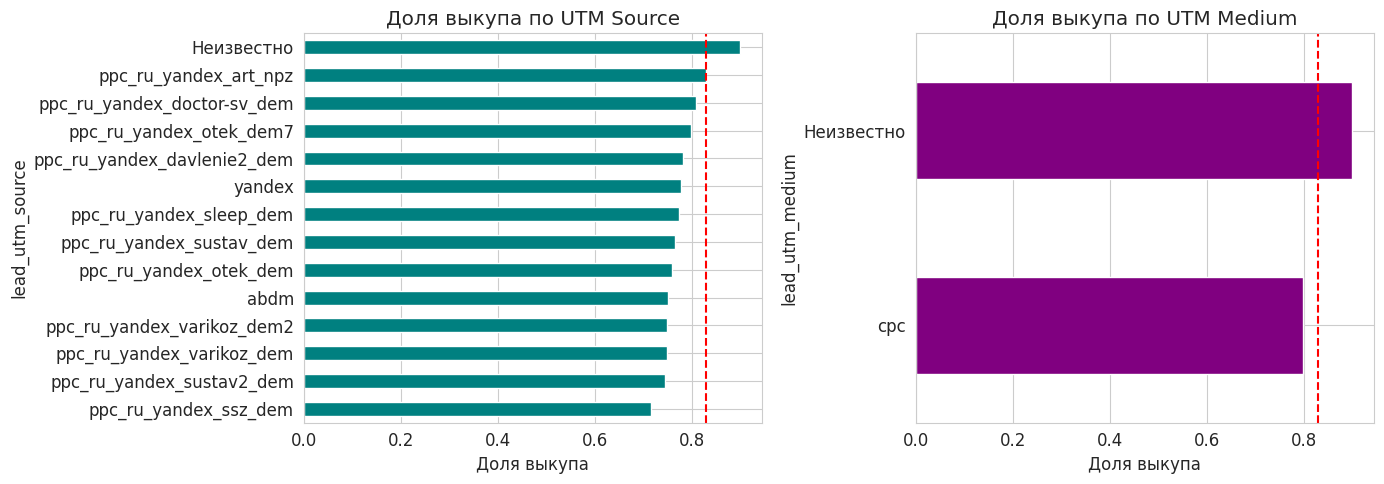

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

utm_source_stats = (
    df.groupby("lead_utm_source").agg({"buyout_flag": ["mean", "count"]}).round(3)
)
utm_source_stats.columns = ["buyout_rate", "count"]
utm_source_stats = utm_source_stats[utm_source_stats["count"] >= 30].sort_values(
    "buyout_rate"
)
utm_source_stats["buyout_rate"].plot(kind="barh", ax=axes[0], color="teal")
axes[0].set_title("Доля выкупа по UTM Source")
axes[0].set_xlabel("Доля выкупа")
axes[0].axvline(x=df["buyout_flag"].mean(), color="red", linestyle="--")

utm_medium_stats = (
    df.groupby("lead_utm_medium").agg({"buyout_flag": ["mean", "count"]}).round(3)
)
utm_medium_stats.columns = ["buyout_rate", "count"]
utm_medium_stats = utm_medium_stats[utm_medium_stats["count"] >= 30].sort_values(
    "buyout_rate"
)
utm_medium_stats["buyout_rate"].plot(kind="barh", ax=axes[1], color="purple")
axes[1].set_title("Доля выкупа по UTM Medium")
axes[1].set_xlabel("Доля выкупа")
axes[1].axvline(x=df["buyout_flag"].mean(), color="red", linestyle="--")

plt.tight_layout()
plt.show()

### 3.6 Квалификация лида

In [ ]:
print("Квалификация лида:")
print(df["lead_Квалификация лида"].value_counts())

print("\nLead Quality:")
print(df["lead_LEADQUALIFYCATION"].value_counts())

Квалификация лида:
lead_Квалификация лида
А - лид       6675
В - лид       3455
С - лид       1991
Неквал лид     179
D - лид         20
Е - лид          4
Name: count, dtype: int64

Lead Quality:
lead_LEADQUALIFYCATION
a    1048
Name: count, dtype: int64


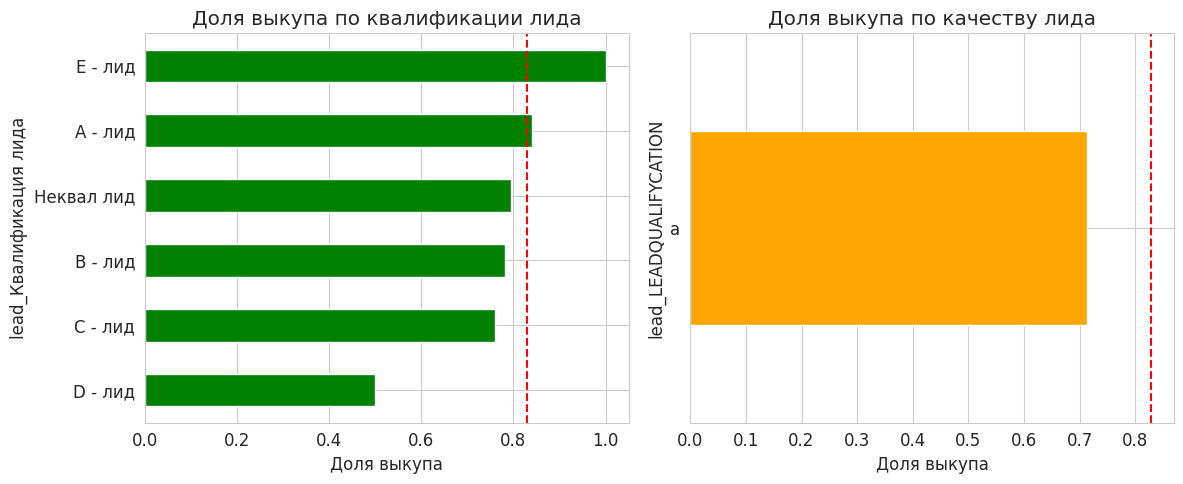

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

qual_stats = df.groupby("lead_Квалификация лида").agg(
    {"buyout_flag": ["mean", "count"]}
)
qual_stats.columns = ["buyout_rate", "count"]
qual_stats = qual_stats.sort_values("buyout_rate")
qual_stats["buyout_rate"].plot(kind="barh", ax=axes[0], color="green")
axes[0].set_title("Доля выкупа по квалификации лида")
axes[0].set_xlabel("Доля выкупа")
axes[0].axvline(x=df["buyout_flag"].mean(), color="red", linestyle="--")

lead_qual_stats = df.groupby("lead_LEADQUALIFYCATION").agg(
    {"buyout_flag": ["mean", "count"]}
)
lead_qual_stats.columns = ["buyout_rate", "count"]
lead_qual_stats = lead_qual_stats.sort_values("buyout_rate")
lead_qual_stats["buyout_rate"].plot(kind="barh", ax=axes[1], color="orange")
axes[1].set_title("Доля выкупа по качеству лида")
axes[1].set_xlabel("Доля выкупа")
axes[1].axvline(x=df["buyout_flag"].mean(), color="red", linestyle="--")

plt.tight_layout()
plt.show()

### 3.7 Продуктовые признаки

In [ ]:
print("Категории товаров:")
print(df["lead_Категория и варианты выбора"].value_counts())

Категории товаров:
lead_Категория и варианты выбора
S                5602
I                2324
D                1367
C                 356
Нет категории     190
Name: count, dtype: int64


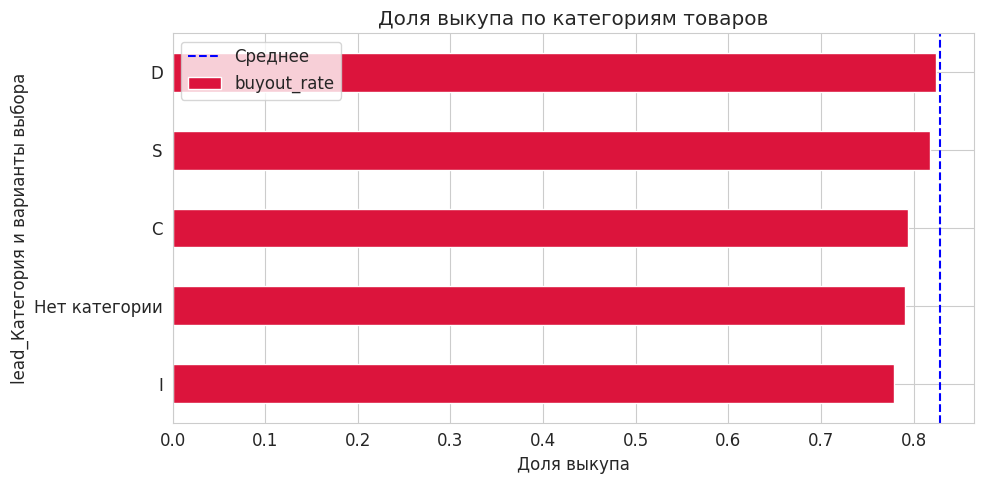

In [ ]:
cat_stats = df.groupby("lead_Категория и варианты выбора").agg(
    {"buyout_flag": ["mean", "count"]}
)
cat_stats.columns = ["buyout_rate", "count"]
cat_stats = cat_stats.sort_values("buyout_rate")

fig, ax = plt.subplots(figsize=(10, 5))
cat_stats["buyout_rate"].plot(kind="barh", ax=ax, color="crimson")
ax.set_title("Доля выкупа по категориям товаров")
ax.set_xlabel("Доля выкупа")
ax.axvline(x=df["buyout_flag"].mean(), color="blue", linestyle="--", label="Среднее")
ax.legend()

plt.tight_layout()
plt.show()

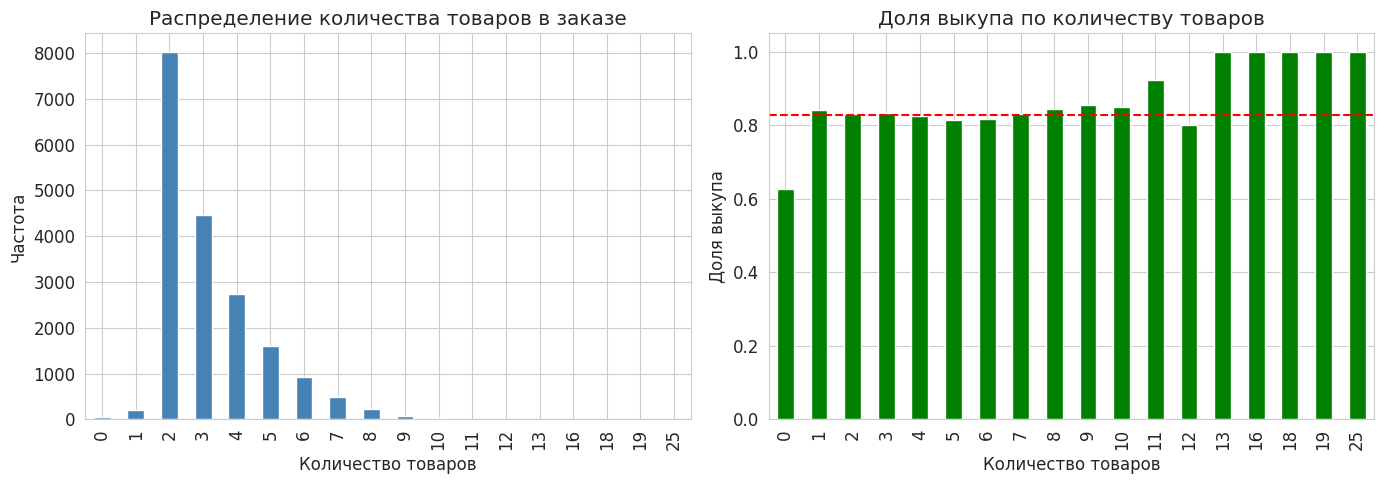

In [ ]:
import re


def count_items(text):
    if pd.isna(text):
        return 0
    return len(re.findall(r"\d+\)\s+[А-Яа-яёЁA-Za-z]", str(text)))


df["n_items"] = df["lead_Состав заказа"].apply(count_items)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["n_items"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="steelblue"
)
axes[0].set_title("Распределение количества товаров в заказе")
axes[0].set_xlabel("Количество товаров")
axes[0].set_ylabel("Частота")

items_buyout = df.groupby("n_items")["buyout_flag"].agg(["mean", "count"])
items_buyout["mean"].plot(kind="bar", ax=axes[1], color="green")
axes[1].set_title("Доля выкупа по количеству товаров")
axes[1].set_xlabel("Количество товаров")
axes[1].set_ylabel("Доля выкупа")
axes[1].axhline(y=df["buyout_flag"].mean(), color="red", linestyle="--")

plt.tight_layout()
plt.show()

## 4. Корреляционный анализ

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude_ts = [
    "sale_ts",
    "lead_created_at",
    "lead_updated_at",
    "contact_created_at",
    "contact_updated_at",
]
numeric_cols = [c for c in numeric_cols if c not in exclude_ts]

correlations = (
    df[numeric_cols + ["buyout_flag"]]
    .corr()["buyout_flag"]
    .drop("buyout_flag")
    .sort_values()
)

print("Признаки с наибольшей положительной корреляцией с выкупом:")
print(correlations.tail(10))

print("\nПризнаки с наибольшей отрицательной корреляцией с выкупом:")
print(correlations.head(10))

Признаки с наибольшей положительной корреляцией с выкупом:
received_ts                      NaN
lead_loss_reason_id              NaN
lead_Индекс отделения отправки   NaN
lead_TILDASPEC-ELEMID            NaN
contact_Whatsgroup_WZ            NaN
lead_ACTUAL-FORMAT               NaN
lead_PCODEVER                    NaN
lead_WIDTH                       NaN
lead_HEIGHT                      NaN
lead_STAT-ID                     NaN
Name: buyout_flag, dtype: float64

Признаки с наибольшей отрицательной корреляцией с выкупом:
days_to_outcome                  -0.701272
lead_Индекс почтомата            -0.299623
current_status_id                -0.273926
lead_status_id                   -0.273926
closed_ts                        -0.251972
lead_closed_at                   -0.161202
returned_ts                      -0.111746
days_handed_to_issued_pvz        -0.107885
lead_Дата приобретения изделия   -0.088397
issued_or_pvz_ts                 -0.044592
Name: buyout_flag, dtype: float64


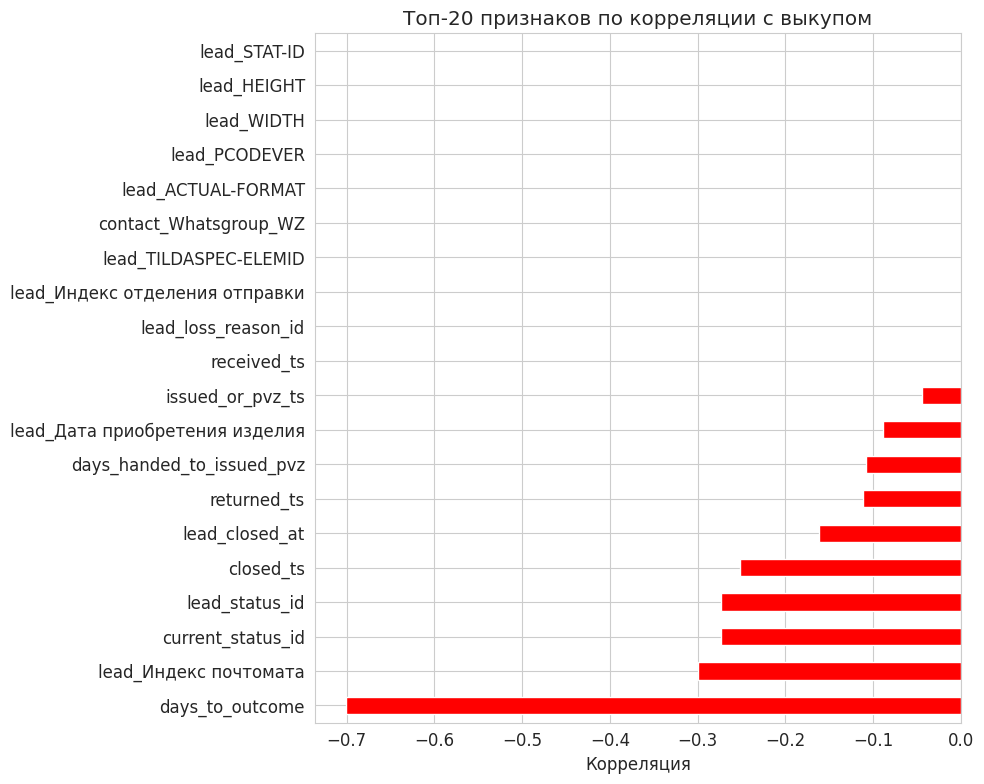

In [ ]:
top_corr = pd.concat([correlations.head(10), correlations.tail(10)])

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["red" if v < 0 else "green" for v in top_corr.values]
top_corr.plot(kind="barh", ax=ax, color=colors)
ax.set_title("Топ-20 признаков по корреляции с выкупом")
ax.set_xlabel("Корреляция")
ax.axvline(x=0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

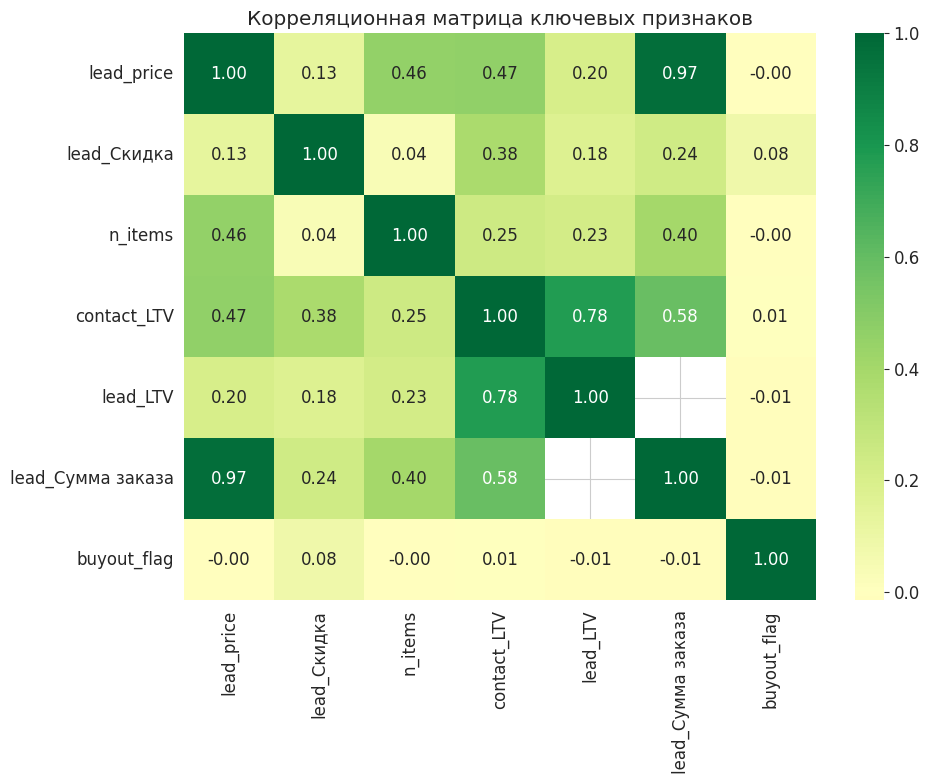

In [ ]:
key_features = [
    "lead_price",
    "lead_Скидка",
    "n_items",
    "contact_LTV",
    "lead_LTV",
    "lead_Сумма заказа",
    "buyout_flag",
]
key_features = [f for f in key_features if f in df.columns]

corr_matrix = df[key_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=ax)
ax.set_title("Корреляционная матрица ключевых признаков")

plt.tight_layout()
plt.show()

## 5. Выявление признаков-утечек

In [ ]:
leakage_columns = [
    "handed_to_delivery_ts",
    "issued_or_pvz_ts",
    "received_ts",
    "rejected_ts",
    "returned_ts",
    "days_sale_to_handed",
    "days_handed_to_issued_pvz",
    "days_to_outcome",
    "lifecycle_incomplete",
    "current_status_id",
    "closed_ts",
    "lead_closed_at",
    "lead_loss_reason_id",
    "outcome_unknown",
]

print("⚠️ ПРИЗНАКИ-УТЕЧКИ (должны быть удалены перед обучением):")
for col in leakage_columns:
    if col in df.columns:
        print(f"  - {col}")

⚠️ ПРИЗНАКИ-УТЕЧКИ (должны быть удалены перед обучением):
  - handed_to_delivery_ts
  - issued_or_pvz_ts
  - received_ts
  - rejected_ts
  - returned_ts
  - days_sale_to_handed
  - days_handed_to_issued_pvz
  - days_to_outcome
  - lifecycle_incomplete
  - current_status_id
  - closed_ts
  - lead_closed_at
  - lead_loss_reason_id
  - outcome_unknown


In [ ]:
high_corr = correlations[abs(correlations) > 0.3]
print("Признаки с |корреляцией| > 0.3:")
if len(high_corr) > 0:
    print(high_corr)
else:
    print("Нет признаков с такой корреляцией")

Признаки с |корреляцией| > 0.3:
days_to_outcome                                 -0.701272
lead_Дата предполагаемой доставки отправления    0.610786
lead_Дата создания накладной СДЭК                0.682566
Name: buyout_flag, dtype: float64


## 6. Выводы и рекомендации

In [ ]:
print("=" * 70)
print("ВЫВОДЫ И РЕКОМЕНДАЦИИ ДЛЯ МОДЕЛИРОВАНИЯ")
print("=" * 70)
print(f"""
1. БАЛАНС КЛАССОВ:
   - Выкуп: {df["buyout_flag"].mean():.1%}, Не выкуп: {1 - df["buyout_flag"].mean():.1%}
   - Умеренный дисбаланс, рекомендуется class_weight='balanced'

2. КЛЮЧЕВЫЕ ПРИЗНАКИ (по корреляции):
   - contact_LTV, contact_Число сделок
   - lead_price, lead_Сумма заказа

3. ВРЕМЕННЫЕ ПАТТЕРНЫ:
   - Выкуп зависит от времени оформления заказа

4. ГЕОГРАФИЯ:
   - Разные города имеют разную долю выкупа

5. ИСТОЧНИКИ ТРАФИКА:
   - UTM Source/Medium влияют на выкуп

6. ПРОДУКТЫ:
   - Категория товара влияет на вероятность выкупа

7. ПРИЗНАКИ-УТЕЧКИ:
   - Удалить все временные метки после оформления

8. РЕКОМЕНДУЕМЫЕ МОДЕЛИ:
   - LightGBM (основная)
   - LogisticRegression (baseline)
""")

ВЫВОДЫ И РЕКОМЕНДАЦИИ ДЛЯ МОДЕЛИРОВАНИЯ

1. БАЛАНС КЛАССОВ:
   - Выкуп: 82.8%, Не выкуп: 17.2%
   - Умеренный дисбаланс, рекомендуется class_weight='balanced'

2. КЛЮЧЕВЫЕ ПРИЗНАКИ (по корреляции):
   - contact_LTV, contact_Число сделок
   - lead_price, lead_Сумма заказа

3. ВРЕМЕННЫЕ ПАТТЕРНЫ:
   - Выкуп зависит от времени оформления заказа

4. ГЕОГРАФИЯ:
   - Разные города имеют разную долю выкупа

5. ИСТОЧНИКИ ТРАФИКА:
   - UTM Source/Medium влияют на выкуп

6. ПРОДУКТЫ:
   - Категория товара влияет на вероятность выкупа

7. ПРИЗНАКИ-УТЕЧКИ:
   - Удалить все временные метки после оформления

8. РЕКОМЕНДУЕМЫЕ МОДЕЛИ:
   - LightGBM (основная)
   - LogisticRegression (baseline)



In [ ]:
processed_path = Path("../data/processed/cleaned_for_eda.parquet")
processed_path.parent.mkdir(parents=True, exist_ok=True)

cols_to_drop = [
    "sale_datetime",
    "created_datetime",
    "sale_month",
    "price_category",
    "has_discount",
    "n_items",
]
df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

df_clean.to_parquet(processed_path, index=False)
print(f"✓ Сохранены очищенные данные: {processed_path}")
print(f"  Формат: {df_clean.shape[0]} строк, {df_clean.shape[1]} колонок")

✓ Сохранены очищенные данные: ../data/processed/cleaned_for_eda.parquet
  Формат: 18887 строк, 191 колонок
